# Data exploration - DL Reaction time HW

### What could affect reaction time?
* Intuitively: Distance traveled with the eyes could be very indicative. When I search for something (e.g. "the" in a text), my eyes jump a lot around the screen until I find it. Then, when I found it, the last step is quite small. Then you stay on it (longer fixated)
* Distance:
    * Large jumps → exploration
    * Small jumps → focused inspection
    * Early large jumps + later small jumps = efficient
    * Random jumps throughout = inefficient
* Time:
    * More randomness in eye movement -> More reaction time
    * Short fixations = scanning / uncertainty
    * Many long fixations → difficult task → slower RT
    * Very short noisy fixations → confusion → slower RT
* Revisiting same region: Uncertainty -> Longer RT
* Spatial coverage
    * Good search: structured coverage (grid-like, systematic)
    * Bad search: clustered or chaotic
* Behavior over time:
    * Early chaos → later focus → fast RT
    * Always chaotic → slow RT

In [115]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

### Load data

In [116]:
DATA_DIR = "scanpaths_split/train_val/"

scanpaths = glob(os.path.join(DATA_DIR, "*.csv"))
print(f"scanpaths: {len(scanpaths)} files")

metadata = pd.read_csv("scanpaths_split/train_val_labels.csv", sep=r"\s+")
rt_dict = dict(zip(metadata.iloc[:, 1], metadata.iloc[:, 0]))

scanpaths: 3696 files


In [117]:
def load_csv(file_path, header='infer', names=None):
    df = pd.read_csv(file_path, sep=r"\s+", header=header, names=names)
    return df

In [118]:
df = load_csv(scanpaths[0])
print(scanpaths[0])
df.head()

scanpaths_split/train_val/23-19.csv


,FPOGX,FPOGY,FPOGD
0,0.57310,0.27285,0.19467
1,0.33746,0.71241,0.22684
2,0.37297,0.73051,0.27414
3,0.38916,0.72370,0.37250
4,0.56965,0.26571,0.24283


### Visualize scanpaths of random samples

In [119]:
def plot_fixation_and_reaction_times(df, title=None):
    x = df["FPOGX"].values
    y = df["FPOGY"].values
    d = df["FPOGD"].values  # duration

    plt.figure(figsize=(6, 6))

    # Plot scanpath (lines between fixations)
    plt.plot(x, y, '-', alpha=0.5, linewidth=1)

    # Plot fixations (size = duration)
    sizes = 200 * (d / d.max())  # normalize for visibility
    plt.scatter(x, y, s=sizes, c=np.arange(len(x)), cmap="viridis", alpha=0.8)

    # Add duration labels
    for i in range(len(x)):
        plt.text(
            x[i], y[i],
            f"{d[i]:.2f}",   # format to 2 decimals
            fontsize=7,
            ha='center',
            va='center'
        )

    # Mark start and end
    plt.scatter(x[0], y[0], c='green', s=100, label="Start")
    plt.scatter(x[-1], y[-1], c='red', s=100, label="End")

    # Optional: annotate order (can get messy for long sequences)
    #for i in range(len(x)):
    #    plt.text(x[i], y[i], str(i), fontsize=6)

    plt.gca().invert_yaxis()  # important for screen coordinates
    plt.title(title if title else "Scanpath")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

In [120]:
def reaction_time_lookup(file_path):
    filename = os.path.basename(file_path)
    return rt_dict[filename]

5.03906


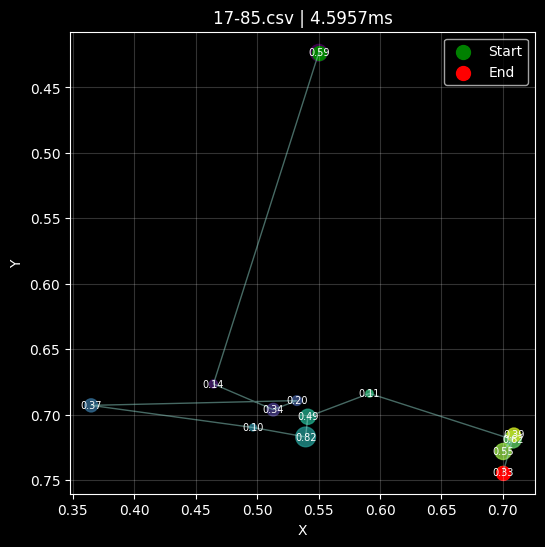

In [121]:
import random
import pandas as pd

idx = random.randint(0, len(scanpaths) - 1)
df = load_csv(scanpaths[idx])
print(df["FPOGD"].sum())

plot_fixation_and_reaction_times(df, title=f"{os.path.basename(scanpaths[idx])} | {reaction_time_lookup(scanpaths[idx])}ms")

## Statistics

### Feature and label distributions

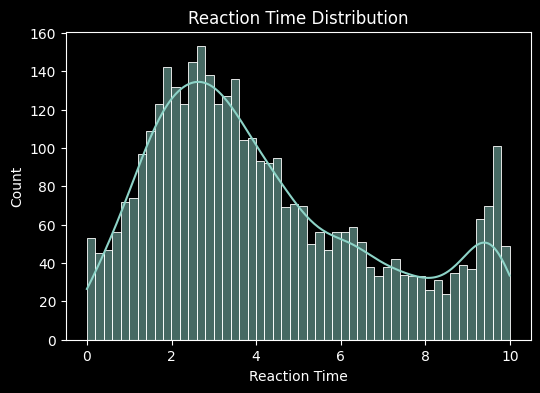

In [140]:
reaction_times = metadata.iloc[:, 0].values

plt.figure(figsize=(6,4))
sns.histplot(reaction_times, bins=50, kde=True)
plt.title("Reaction Time Distribution")
plt.xlabel("Reaction Time")
plt.ylabel("Count")
plt.show()

The mode on the right-hand side is making me think if that's the time where people give up or where it was cut-off maybe?

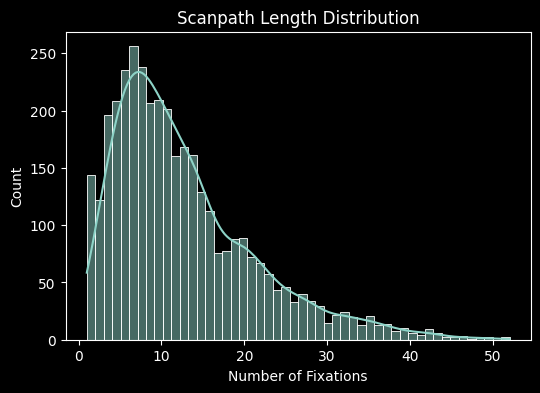

In [123]:
lengths = []

for path in scanpaths:
    df = load_csv(path)
    lengths.append(len(df))

plt.figure(figsize=(6,4))
sns.histplot(lengths, bins=50, kde=True)
plt.title("Scanpath Length Distribution")
plt.xlabel("Number of Fixations")
plt.show()

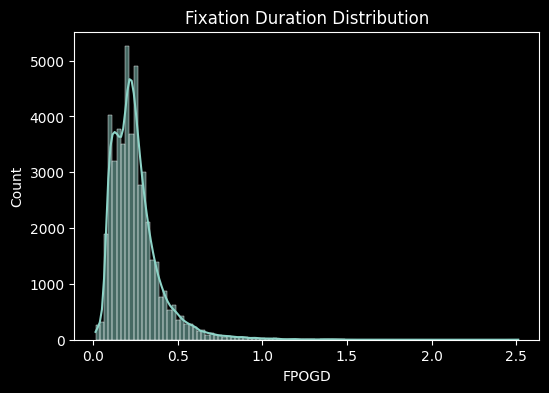

In [124]:
durations = []

for path in scanpaths:
    df = load_csv(path)
    durations.extend(df["FPOGD"].values)

plt.figure(figsize=(6,4))
sns.histplot(durations, bins=100, kde=True)
plt.title("Fixation Duration Distribution")
plt.xlabel("FPOGD")
plt.show()

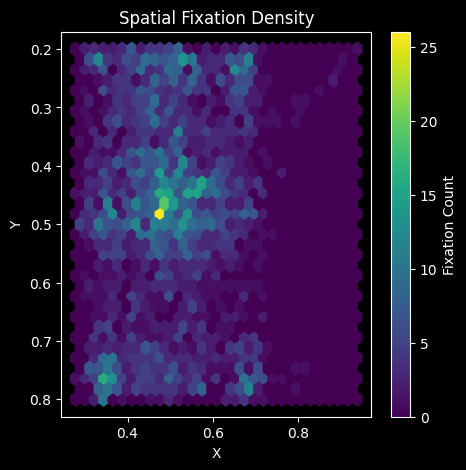

In [125]:
all_x, all_y = [], []

for path in scanpaths[:200]:  # subset for speed
    df = load_csv(path)
    all_x.extend(df["FPOGX"].values)
    all_y.extend(df["FPOGY"].values)

plt.figure(figsize=(5,5))
hb = plt.hexbin(all_x, all_y, gridsize=30, cmap='viridis')
plt.colorbar(hb, label="Fixation Count")
plt.title("Spatial Fixation Density")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().invert_yaxis()
plt.show()

### Basic Correlations between Features

In [126]:
import os

features = []
targets = []

for path in scanpaths:
    df = load_csv(path)
    file_name = os.path.basename(path)
    try:
        rt = rt_dict[file_name]
    except:
        pass

    features.append([
        len(df),                      # number of fixations
        df["FPOGD"].mean(),
        df["FPOGD"].std(),
        df["FPOGD"].max(),
    ])
    targets.append(rt)

features = np.array(features)
targets = np.array(targets)

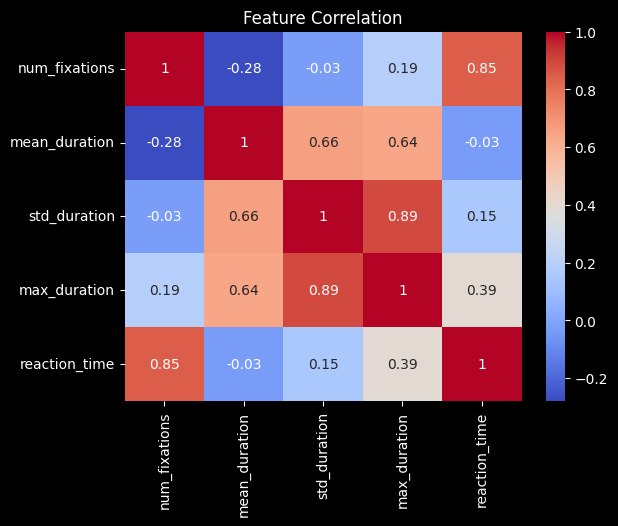

In [127]:
df_feat = pd.DataFrame(features, columns=[
    "num_fixations",
    "mean_duration",
    "std_duration",
    "max_duration"
])
df_feat["reaction_time"] = targets

sns.heatmap(df_feat.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

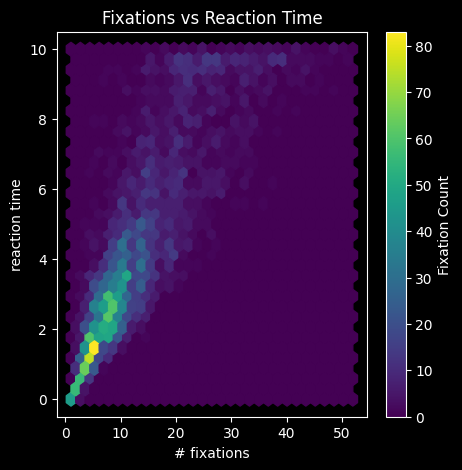

In [135]:
plt.figure(figsize=(5,5))
hb = plt.hexbin(df_feat["num_fixations"], df_feat["reaction_time"], gridsize=30, cmap='viridis')
plt.colorbar(hb, label="Fixation Count")
plt.title("Fixations vs Reaction Time")
plt.xlabel("Number of fixations")
plt.ylabel("reaction time")
plt.show()


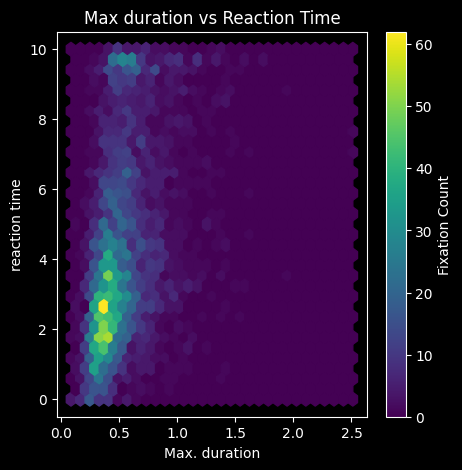

In [138]:
plt.figure(figsize=(5,5))
hb = plt.hexbin(df_feat["max_duration"], df_feat["reaction_time"], gridsize=30, cmap='viridis')
plt.colorbar(hb, label="Fixation Count")
plt.title("Max duration vs Reaction Time")
plt.xlabel("Max. duration")
plt.ylabel("reaction time")
plt.show()

Obviously, we have the more fixations the higher the reaction time.

Interestingly, the mean duration time is not so important, but the max_duration time is.

### Split reaction times into different regions

In [ ]:
# Todo: Look into multimodality, once I have important input features identified.
#fixation count
#duration
#path length
low_rt  = df_feat[df_feat["reaction_time"] < 4.5]
mid_rt  = df_feat[(df_feat["reaction_time"] >= 4.5) & (df_feat["reaction_time"] < 8)]
high_rt = df_feat[df_feat["reaction_time"] >= 8]

### Ideas

* Anzahl der Punkte
* Distanz Start- zu Endpunkt
* Summe der Durationpoints
* Einzelner Punkt: Da waren es 0s

### Insights
* Number of fixations = strong feature. High correlation with reaction time.
* Max duration time also correlates with RT. Worth integrating.
* Multimodality: Reaction times have a second mode near 10s. The max. duration is almost exactly 10s.
    * It does not seem like a cut-off, as many points are there.
    * nn.SmoothL1Loss() could be a good loss function
* Hardly skewed input features: Fixation duration and number of fixations.
    * Log transform them: d_log = np.log1p(FPOGD), then x = (x - mean) / std